In [ ]:
!C:\Users\toy_3\AppData\Local\Programs\Python\Python39\python.exe -m pip install pandas scikit-learn

In [24]:
import pandas as pd
from sklearn.datasets import fetch_openml

In [25]:
mnist = fetch_openml('mnist_784',as_frame=False)

In [39]:
X, y= mnist.data, mnist.target
X
X.shape
y
y.shape

(70000,)

In [40]:
import matplotlib.pyplot as plt

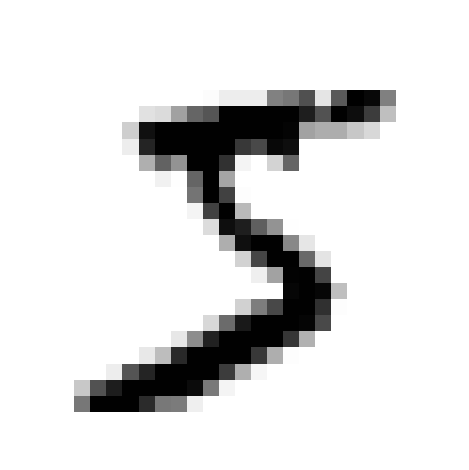

4


In [54]:
def plot_digit(image_data):
    image = image_data.reshape(28, 28)
    plt.imshow(image, cmap="binary")
    plt.axis("off")

def save_fig(fig_id, tight_layout=True, fig_extension="png", resolution=300):
    path = f"{fig_id}.{fig_extension}"
    if tight_layout:
        plt.tight_layout()
    plt.savefig(path, format=fig_extension, dpi=resolution)

some_digit = X[0]
plot_digit(some_digit)
save_fig("some_digit_plot")
plt.show()
print(y[9])

In [ ]:
x_train, x_test, y_train, y_test = X[:60000], X[60000:], y[:60000], y[60000:]

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]])

In [ ]:
# is number is 5 or not 
# binary classification
# use Stochastic Gradient Descent model
from sklearn.linear_model import SGDClassifier

y_train_5 = (y_train == '5')
y_test_5 = (y_test == "5")

sgd_clf = SGDClassifier(random_state=42)
sgd_clf.fit(x_train,y_train_5)

SGDClassifier(random_state=42)

In [55]:
sgd_clf.predict([some_digit])

array([ True])

In [56]:
from sklearn.model_selection import cross_val_score
cross_val_score(sgd_clf, x_train, y_train_5, cv = 3, scoring = "accuracy")

array([0.95035, 0.96035, 0.9604 ])

In [59]:
from sklearn.dummy import DummyClassifier

dummy_clf = DummyClassifier()
dummy_clf.fit(x_train, y_train_5)
print(any(dummy_clf.predict(x_train)))

cross_val_score(dummy_clf,x_train, y_train_5, cv = 3, scoring="accuracy")

False


array([0.90965, 0.90965, 0.90965])

In [65]:
# k-folds
from sklearn.model_selection import StratifiedKFold
from sklearn.base import clone

skfolds = StratifiedKFold(n_splits = 3) # k = 3

for train_index, test_index in skfolds.split(x_train, y_train_5):
    clone_clf = clone(sgd_clf)
    x_train_fold = x_train[train_index]
    y_train_fold = y_train_5[train_index]
    x_test_fold = x_train[test_index]
    y_test_fold = y_train_5[test_index]

    clone_clf.fit(x_train_fold, y_train_fold)
    y_pred = clone_clf.predict(x_test_fold)
    n_correct = sum(y_pred == y_test_fold)
    print(n_correct / len(y_pred))


0.95035
0.96035
0.9604


In [67]:
from sklearn.model_selection import cross_val_predict

y_train_pred = cross_val_predict(sgd_clf, x_train, y_train_5, cv = 3)



In [69]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_train_5, y_train_pred)
cm

array([[53892,   687],
       [ 1891,  3530]])

In [ ]:
# precision and recall
from sklearn.metrics import precision_score, recall_score, f1_score
pc5 = precision_score(y_train_5, y_train_pred) 
rc5 = recall_score(y_train_5, y_train_pred)
f1_5 = f1_score(y_train_5, y_train_pred)
print(pc5, rc5, f1_5)

0.8370879772350012 0.6511713705958311 0.7325171197343847
